# 8 - Indici di Forma con R

Questo notebook copre gli **indici di forma** di una distribuzione:
1. **Asimmetria (Skewness)** — misura della simmetria della distribuzione
2. **Curtosi (Kurtosis)** — misura del "picco" e delle code della distribuzione
3. **Confronto con il dataset Diamonds** — analisi della variabile `price`
4. **Half-violin plot** — visualizzazione combinata con boxplot

---
## Generiamo una distribuzione normale di riferimento

Generiamo 100.000 valori da una N(10, 2) come distribuzione di riferimento simmetrica.

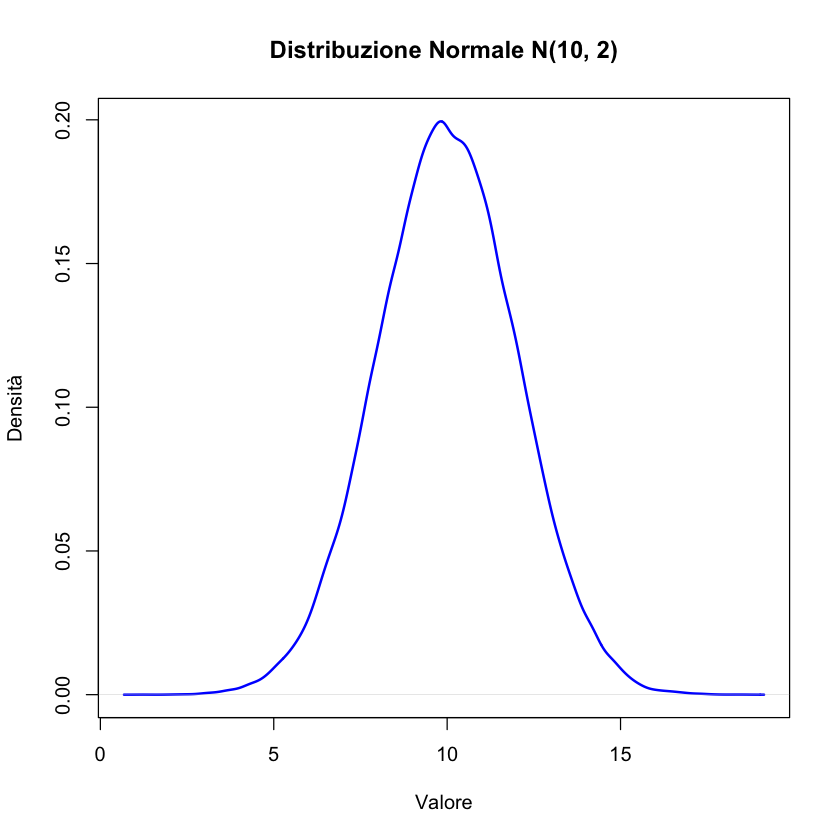

In [1]:
# Generiamo una distribuzione normale N(10, 2)
x <- rnorm(100000, 10, 2)

# Densità
plot(density(x),
     main = "Distribuzione Normale N(10, 2)",
     xlab = "Valore", ylab = "Densità",
     col = "blue", lwd = 2)

---
## 1. Asimmetria (Skewness)

L'**indice di asimmetria di Fisher** misura quanto una distribuzione è simmetrica:
$$\text{Asimmetria} = \frac{m_3}{\sigma^3} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \mu)^3}{\sigma^3}$$

- **= 0** → distribuzione simmetrica (come la normale)
- **> 0** → asimmetria positiva (coda a destra)
- **< 0** → asimmetria negativa (coda a sinistra)

In [2]:
# Calcolo manuale dell'asimmetria
mu <- mean(x)
sigma <- sd(x)

# Momento centrale di ordine 3
m3 <- sum((x - mu)^3) / length(x)

# Indice di asimmetria di Fisher
asim.fisher <- m3 / sigma^3
asim.fisher

[1] -0.005508132

---
## 2. Curtosi (Kurtosis)

La **curtosi** misura la "concentrazione" dei dati attorno alla media e lo spessore delle code:
$$\text{Curtosi} = \frac{m_4}{\sigma^4} - 3 = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \mu)^4}{\sigma^4} - 3$$

Si sottrae 3 perché la normale standard ha curtosi = 3 (si usa la **curtosi in eccesso**):
- **= 0** → mesocurtica (come la normale)
- **> 0** → leptocurtica (picco più alto, code più pesanti)
- **< 0** → platicurtica (picco più basso, code più leggere)

In [3]:
# Calcolo manuale della curtosi
# Momento centrale di ordine 4
m4 <- sum((x - mu)^4) / length(x)

# Curtosi in eccesso (si sottrae 3)
curtosi <- m4 / sigma^4 - 3
curtosi

[1] -0.01364939

---
## 3. Usando il pacchetto `moments`

Il pacchetto `moments` fornisce funzioni built-in per calcolare asimmetria e curtosi.

In [ ]:
# Installiamo e carichiamo il pacchetto moments
# install.packages("moments")
library(moments)

# Asimmetria con funzione built-in
skewness(x)

# Curtosi con funzione built-in (NOTA: kurtosis() restituisce la curtosi NON in eccesso)
kurtosis(x)  # per la normale vale ~3
kurtosis(x) - 3  # curtosi in eccesso


The downloaded binary packages are in
	/var/folders/p3/80498z8x71z1_xfxtnstpxkc0000gn/T//Rtmp7MA8QZ/downloaded_packages


[1] -0.005508214

[1] 2.98641

[1] -0.01358967

---
## 4. Analisi del dataset Diamonds

Carichiamo il dataset `diamonds` e analizziamo la variabile `price` (prezzo).
Il prezzo dei diamanti ha tipicamente una distribuzione **asimmetrica positiva** (coda a destra).

In [12]:
library(ggplot2)
data("diamonds")

# Riepilogo del dataset
summary(diamonds)

# Attach per accesso diretto
attach(diamonds)

     carat               cut        color        clarity          depth      
 Min.   :0.2000   Fair     : 1610   D: 6775   SI1    :13065   Min.   :43.00  
 1st Qu.:0.4000   Good     : 4906   E: 9797   VS2    :12258   1st Qu.:61.00  
 Median :0.7000   Very Good:12082   F: 9542   SI2    : 9194   Median :61.80  
 Mean   :0.7979   Premium  :13791   G:11292   VS1    : 8171   Mean   :61.75  
 3rd Qu.:1.0400   Ideal    :21551   H: 8304   VVS2   : 5066   3rd Qu.:62.50  
 Max.   :5.0100                     I: 5422   VVS1   : 3655   Max.   :79.00  
                                    J: 2808   (Other): 2531                  
     table           price             x                y         
 Min.   :43.00   Min.   :  326   Min.   : 0.000   Min.   : 0.000  
 1st Qu.:56.00   1st Qu.:  950   1st Qu.: 4.710   1st Qu.: 4.720  
 Median :57.00   Median : 2401   Median : 5.700   Median : 5.710  
 Mean   :57.46   Mean   : 3933   Mean   : 5.731   Mean   : 5.735  
 3rd Qu.:59.00   3rd Qu.: 5324   3rd Qu.:

The following object is masked _by_ .GlobalEnv:

    x


The following objects are masked from diamonds (pos = 4):

    carat, clarity, color, cut, depth, price, table, x, y, z


The following objects are masked from diamonds (pos = 5):

    carat, clarity, color, cut, depth, price, table, x, y, z




Warning message in geom_histogram(aes(x = price), stat = "density", col = "lightblue", :
“Ignoring unknown parameters: `binwidth` and `bins`”


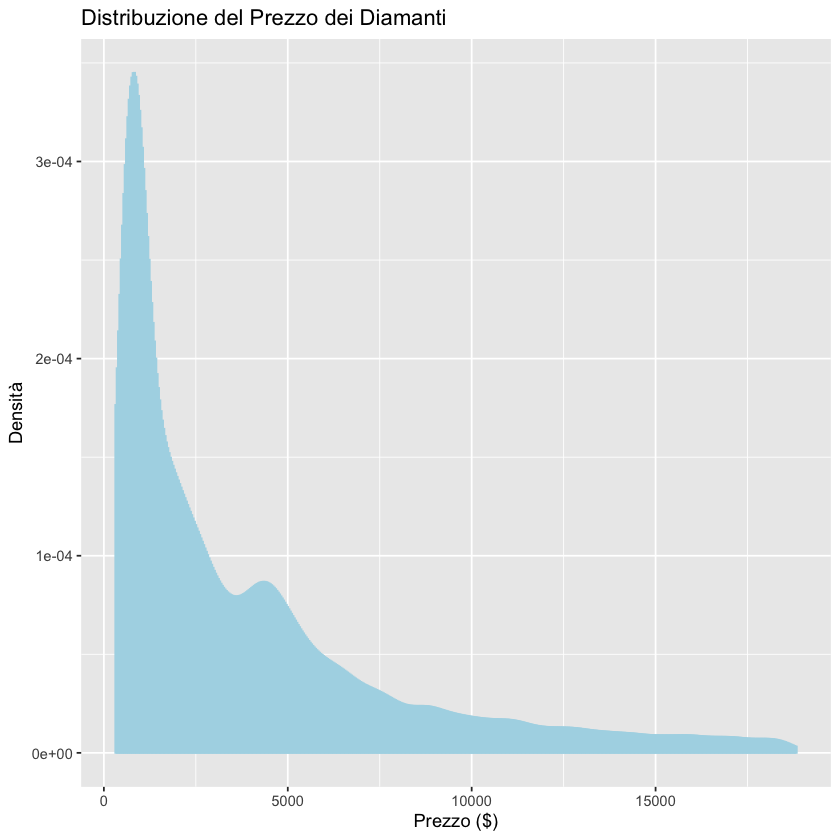

In [13]:
# Istogramma del prezzo (densità)
ggplot() +
  geom_histogram(aes(x = price),
                 stat = "density",
                 col = "lightblue",
                 fill = "lightblue") +
  labs(title = "Distribuzione del Prezzo dei Diamanti",
       x = "Prezzo ($)", y = "Densità")

In [14]:
# Asimmetria e curtosi del prezzo
skewness(price)
kurtosis(price) - 3  # curtosi in eccesso

# Media e mediana: se media > mediana → asimmetria positiva
mean(price)
median(price)

# Tabella delle frequenze (per vedere i valori più frequenti)
# View(table(price))

[1] 1.61835

[1] 2.177383

[1] 3932.8

[1] 2401

---
## 5. Half-violin Plot

Usiamo il pacchetto `gghalves` per creare un grafico combinato:
- **Half-violin plot** a sinistra — mostra la densità
- **Boxplot** a destra — mostra mediana, quartili e outlier

Confrontiamo la distribuzione del prezzo per ogni tipo di taglio (`cut`).

In [ ]:
# Installiamo e carichiamo gghalves
# install.packages("gghalves")
library(gghalves)

# Half-violin + boxplot per prezzo raggruppato per cut
ggplot(data = diamonds) +
  theme_classic() +
  geom_half_violin(mapping = aes(x = cut, y = price),
                   side = "l", fill = "lightblue") +
  geom_half_boxplot(mapping = aes(x = cut, y = price),
                    side = "r", fill = "pink") +
  labs(title = "Distribuzione del Prezzo per Taglio (Cut)",
       x = "Taglio", y = "Prezzo ($)")

Warning message:
“package ‘gghalves’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


ERROR: Error in library(gghalves): there is no package called ‘gghalves’
